# Credit Approval Dataset ML Pipeline
This notebook performs preprocessing, feature selection, and machine learning modeling on the UCI Credit Approval dataset. Models include Logistic Regression, SVM, KNN, Decision Tree, and Random Forest, compared by Accuracy, Precision, Recall, and F1.

In [54]:
# Credit Approval ML pipeline

import os
import numpy as np
import pandas as pd
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Read the Dataset

In [55]:
# 1) Load dataset
uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data'
local_filename = 'crx.data'


if not os.path.exists(local_filename):
  try:
    print('Downloading dataset from UCI...')
    urllib.request.urlretrieve(uci_url, local_filename)
    print('Downloaded to', local_filename)
  except Exception as e:
    print('Could not download dataset automatically. Please download manually from:')
    print(uci_url)



# column names: A1..A15 and the last column is the class
col_names = [f'A{i}' for i in range(1, 16)] + ['class']


df = pd.read_csv(local_filename, header=None, names=col_names, na_values='?')

Downloaded to crx.data


# EDA Dataset (Find missing + string columns)

In [56]:
df.info()

print("\nMissing values per column:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  class   690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB

Missing values per column:


A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
class     0
dtype: int64

# Remove Missing Values

In [57]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

print("Categorical cols:", list(categorical_cols))
print("Numeric cols:", list(numerical_cols))

numerical_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

print("\nAfter imputation missing counts:")
print(df.isnull().sum())

Categorical cols: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'class']
Numeric cols: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

After imputation missing counts:
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
A15      0
class    0
dtype: int64


# Perform Label Encoding on String Columns

In [58]:
# Encode features except "class"
categorical_features = [col for col in categorical_cols if col != "class"]

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Encode the "class" column separately
le_class = LabelEncoder()
df["class"] = le_class.fit_transform(df["class"])

# Build mapping: original label → encoded value
class_mapping = dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))
print("Class mapping:", class_mapping)

Class mapping: {'+': np.int64(0), '-': np.int64(1)}


# Remove Outliers from Data

In [59]:
numeric_features = [col for col in numerical_cols]

print("Numeric features used for outlier removal:", numeric_features)

Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[numeric_features] < lower) | (df[numeric_features] > upper)).any(axis=1)

print("Rows before outlier removal:", df.shape[0])
df_no_out = df[mask].copy()
print("Rows after outlier removal:", df_no_out.shape[0], "(removed", df.shape[0] - df_no_out.shape[0], "rows)")

Numeric features used for outlier removal: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Rows before outlier removal: 690
Rows after outlier removal: 473 (removed 217 rows)


# Feature Selection Through Correlation with Corr threshold= 0.05

In [60]:
df = df_no_out

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Get absolute correlation with the target column "class"
corr_with_target = corr_matrix["class"].abs().sort_values(ascending=False)
print("Absolute correlation with target:\n", corr_with_target)

# Feature selection threshold
threshold = 0.05
selected_features = corr_with_target[corr_with_target > threshold].index.tolist()

# Remove "class" itself
selected_features = [feat for feat in selected_features if feat != "class"]

print(f"\nSelected features by correlation (threshold={threshold}):\n", selected_features)
print("\nFinal features used for modeling:", selected_features)

Absolute correlation with target:
 class    1.000000
A9       0.673597
A11      0.390429
A10      0.343816
A8       0.312195
A15      0.266267
A4       0.176275
A5       0.176275
A3       0.152456
A6       0.126197
A13      0.042882
A2       0.034631
A1       0.030391
A14      0.004195
A7       0.003786
A12      0.001446
Name: class, dtype: float64

Selected features by correlation (threshold=0.05):
 ['A9', 'A11', 'A10', 'A8', 'A15', 'A4', 'A5', 'A3', 'A6']

Final features used for modeling: ['A9', 'A11', 'A10', 'A8', 'A15', 'A4', 'A5', 'A3', 'A6']


# Split the data into X and y dataframes

In [61]:
X = df[selected_features]
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (473, 9)
y shape: (473,)


# Split the data in Train-Test Parts

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train/test sizes: ({X_train.shape}) ({X_test.shape})")

Train/test sizes: ((378, 9)) ((95, 9))


# Normalize the values using Standard Scaling

In [63]:
# Standardize numeric features (all features are numeric now after encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Following models over the dataset:


1.   LogisticRegression
2.   SVM
3.   KNN
4.   DecisionTrees
5.   RandomForest



# Find F1 Score, Precision, Recall and Confusion Matrix for each model

In [64]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    print("Training", name)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

Training Logistic Regression
Logistic Regression Accuracy: 0.8316
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        31
           1       0.86      0.89      0.88        64

    accuracy                           0.83        95
   macro avg       0.81      0.80      0.81        95
weighted avg       0.83      0.83      0.83        95

------------------------------------------------------------
Training SVM
SVM Accuracy: 0.7895
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        31
           1       0.83      0.86      0.85        64

    accuracy                           0.79        95
   macro avg       0.76      0.75      0.76        95
weighted avg       0.79      0.79      0.79        95

------------------------------------------------------------
Training KNN
KNN Accuracy: 0.8000
              precision    recall  f1-score   support

           0       0.77      0.55  

# Make a Dataframe containing all the results

In [65]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

results_df = pd.DataFrame(results)
print("Comparison table:")
print(results_df)

Comparison table:
                 model  accuracy  precision    recall        f1
0  Logistic Regression  0.831579   0.829368  0.831579  0.830067
1                  SVM  0.789474   0.786449  0.789474  0.787584
2                  KNN  0.800000   0.796638  0.800000  0.789588
3        Decision Tree  0.768421   0.760842  0.768421  0.761200
4        Random Forest  0.842105   0.841240  0.842105  0.836151


# Make a Comparison Graph b/w all the models

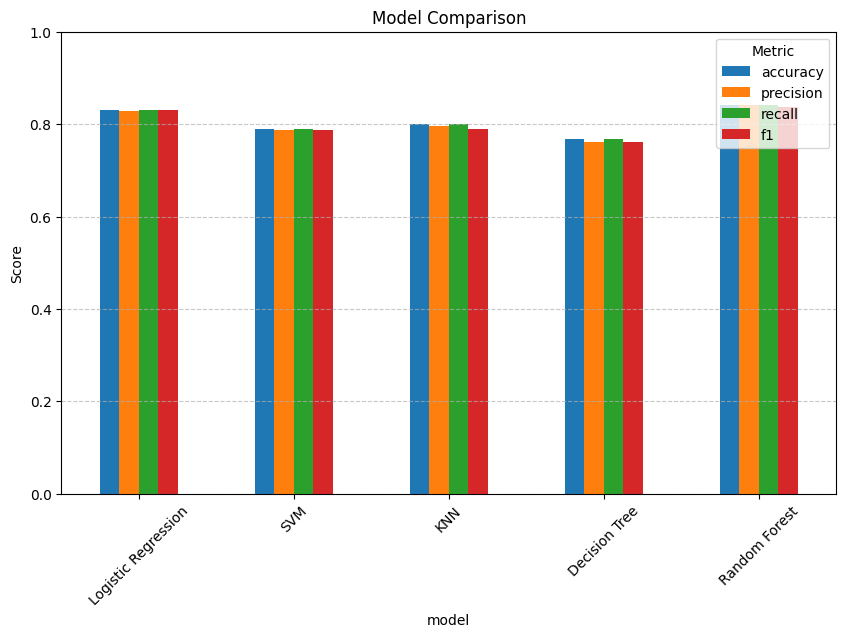

In [66]:
# Set index to model names
results_df_plot = results_df.set_index("model")

# Plot all metrics side by side
results_df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# Print Confusion matrix here

In [67]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Confusion matrix for {name}:")
    print(cm)

Confusion matrix for Logistic Regression:
[[22  9]
 [ 7 57]]
Confusion matrix for SVM:
[[20 11]
 [ 9 55]]
Confusion matrix for KNN:
[[17 14]
 [ 5 59]]
Confusion matrix for Decision Tree:
[[17 14]
 [ 8 56]]
Confusion matrix for Random Forest:
[[20 11]
 [ 4 60]]
